# Layered Soil System with PyDynSM: Parts 1 to 3

This notebook reproduces the soil-only analysis with `PyDynSM`, using one exact `Shear Beam` element per soil layer.

The mapping to the SH-wave soil model is:

- the element axis is used as the depth coordinate
- the active `z` DOF of the `Shear Beam` is interpreted as the horizontal SH displacement
- `A = 1`, so `\rho A = \rho` and `GA = G`

With that choice, the three-layer PyDynSM model should reproduce the same natural frequencies, mode shapes, and FRFs as the earlier notebook.


In [2]:
# restart
import io
from contextlib import redirect_stdout

import matplotlib.pyplot as plt
import numpy as np
import pydynsm as PDM
import scipy.optimize as opt
from scipy.signal import find_peaks

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["lines.linewidth"] = 1.5


In [3]:
# problem values defined from the student-ID digits, matching Assignment.2.EQ.py
A, B, C, D, E, F, G = 6, 6, 1, 1, 2, 5, 7

student_digits = {"A": A, "B": B, "C": C, "D": D, "E": E, "F": F, "G": G}

M = (800 + 10 * F) * 1e3
J = 300e6
rho_t = 7850.0
Et = 210e9
xi_t = 0.001
D_out_1 = 9.1
D_inner_1 = 8.96
D_out_2 = 7.1
D_inner_2 = 7.0
F_w = 2e5

H_t = 140 + A
H_w = 30 + F
H1_thickness = 2 + B
H2_thickness = 58 + G
H3_thickness = 38 + F

G1 = (100 + 10 * F) * 1e6
rho1 = 1650.0
eta1 = 1000.0 + 10.0 * C

G2 = (100 + 10 * D) * 1e6
rho2 = 1850.0
eta2 = 1000.0 + 10.0 * E

G3 = (100 + 10 * E) * 1e6
rho3 = 1900.0
eta3 = 1000.0 + 10.0 * D

print("Student-ID digits used in this notebook:")
print(student_digits)


Student-ID digits used in this notebook:
{'A': 6, 'B': 6, 'C': 1, 'D': 1, 'E': 2, 'F': 5, 'G': 7}


## 1. Governing Equations and Shear-Beam Equivalence

For one-dimensional SH-wave propagation, each soil layer satisfies

$$
\rho_i \frac{\partial^2 u_i}{\partial t^2} - G_i \frac{\partial^2 u_i}{\partial z^2} = 0,
\qquad
c_i = \sqrt{\frac{G_i}{\rho_i}}.
$$

With the harmonic ansatz

$$
u_i(z,t) = U_i(z)e^{i\omega t},
$$

the layer-wise equation becomes

$$
G_i U_i''(z) + \rho_i \omega^2 U_i(z) = 0.
$$

A `PyDynSM` `Shear Beam` element satisfies the same frequency-domain equation,

$$
GA\,U''(x) + \rho A\,\omega^2 U(x) = 0.
$$

Therefore, if we choose

$$
A = 1,
\qquad
\rho A = \rho_i,
\qquad
GA = G_i,
$$

then each soil layer is represented exactly by one `Shear Beam` element.

The boundary and interface conditions are enforced in the model as follows:

- free surface at the top: no support is applied at the surface node
- displacement continuity at the interfaces: adjacent elements share the same node
- stress continuity at the interfaces: assembly of the element forces enforces continuity of `GA U'`
- fixed base for free vibration: the bedrock node is fixed
- prescribed base motion for part 3: the same bedrock DOF is used as a prescribed displacement when evaluating the FRF


In [4]:
# values used in the PyDynSM soil model
layer_thicknesses = np.array([float(H1_thickness), float(H2_thickness), float(H3_thickness)])
layer_G = np.array([float(G1), float(G2), float(G3)])
layer_rho = np.array([float(rho1), float(rho2), float(rho3)])
layer_eta = np.array([float(eta1), float(eta2), float(eta3)])
layer_ksi = np.zeros(3)

c_layers = np.sqrt(layer_G / layer_rho)

x_nodes = np.array(
    [
        0.0,
        layer_thicknesses[0],
        layer_thicknesses[0] + layer_thicknesses[1],
        layer_thicknesses.sum(),
    ]
)
depth_nodes = -x_nodes

print("Soil thicknesses [m]:", layer_thicknesses)
print("Shear moduli [Pa]:", layer_G)
print("Densities [kg/m^3]:", layer_rho)
print("Shear-wave velocities [m/s]:", np.round(c_layers, 4))
print("Depth coordinates used for plotting [m]:", depth_nodes)


Soil thicknesses [m]: [ 8. 65. 43.]
Shear moduli [Pa]: [1.5e+08 1.1e+08 1.2e+08]
Densities [kg/m^3]: [1650. 1850. 1900.]
Shear-wave velocities [m/s]: [301.5113 243.8431 251.3123]
Depth coordinates used for plotting [m]: [  -0.   -8.  -73. -116.]


In [5]:
def build_soil_column(ksi_values=None):
    if ksi_values is None:
        ksi_values = np.zeros(3)

    ksi_values = np.asarray(ksi_values, dtype=float)

    buffer = io.StringIO()
    with redirect_stdout(buffer):
        structure = PDM.Assembler("Three-layer soil column")
        nodes = [
            structure.CreateNode(float(x_coord), 0.0, dof_config=["z"])
            for x_coord in x_nodes
        ]

        for i in range(3):
            element = structure.CreateElement([nodes[i], nodes[i + 1]])
            element.SetSection(
                "Shear Beam",
                {
                    "rho": layer_rho[i],
                    "A": 1.0,
                    "G": layer_G[i],
                    "ksi": ksi_values[i],
                },
            )

        nodes[-1].fix_node("z")
        structure.run_connectivity()

    return structure, nodes


def constrained_matrix(structure, omega):
    return structure.GlobalConstrainedStiffness(float(omega))


def smallest_singular_value(structure, omega):
    K_ff = constrained_matrix(structure, omega)
    return float(np.min(np.linalg.svd(K_ff, compute_uv=False)))


def find_natural_frequencies(
    structure,
    omega_min=0.1,
    omega_max=80.0,
    n_scan=20000,
    n_modes=10,
):
    omega_scan = np.linspace(omega_min, omega_max, n_scan)
    sigma_scan = np.array([smallest_singular_value(structure, omega) for omega in omega_scan])

    # det(K_ff) = 0 at resonance. For the complex PyDynSM matrix, sigma_min(K_ff)
    # is more robust numerically than scanning the real or imaginary part of det(K_ff).
    indicator = -np.log10(np.maximum(sigma_scan, 1e-30))
    peak_indices, _ = find_peaks(
        indicator,
        prominence=0.5,
        distance=max(80, n_scan // 120),
    )
    peak_indices = peak_indices[np.argsort(omega_scan[peak_indices])]

    omega_n = []
    for idx in peak_indices:
        left = omega_scan[max(idx - 20, 0)]
        right = omega_scan[min(idx + 20, n_scan - 1)]
        result = opt.minimize_scalar(
            lambda w: smallest_singular_value(structure, w),
            bounds=(left, right),
            method="bounded",
        )

        if omega_n and abs(result.x - omega_n[-1]) < 1e-3:
            continue

        omega_n.append(float(result.x))

        if len(omega_n) == n_modes:
            break

    return omega_scan, sigma_scan, np.array(omega_n)


def mode_vector(structure, omega):
    K_ff = constrained_matrix(structure, omega)
    _, _, vh = np.linalg.svd(K_ff)
    phi_free = vh[-1, :].astype(complex)

    reference_index = int(np.argmax(np.abs(phi_free)))
    phi_free = phi_free / phi_free[reference_index]

    if np.real(phi_free[0]) < 0:
        phi_free = -phi_free

    return phi_free


def mode_profile(structure, omega, num_points_per_layer=250):
    phi_free = mode_vector(structure, omega)
    u_full = structure.FullDisplacement(phi_free)
    element_displacements = structure.ElementDisplacements(
        u_full,
        omega,
        num_points=num_points_per_layer,
        local_axes=True,
    )

    depth_parts = []
    disp_parts = []

    for element in structure.elements:
        x_left = element.nodes[0].x
        x_right = element.nodes[1].x
        x_plot = np.linspace(x_left, x_right, num_points_per_layer)
        depth_plot = -x_plot
        disp_plot = np.asarray(np.real_if_close(element_displacements[element.id][1]), dtype=complex)

        if depth_parts:
            depth_plot = depth_plot[1:]
            disp_plot = disp_plot[1:]

        depth_parts.append(depth_plot)
        disp_parts.append(disp_plot)

    depth = np.concatenate(depth_parts)
    displacement = np.concatenate(disp_parts)

    max_abs = np.max(np.abs(displacement))
    if max_abs > 0:
        displacement = displacement / max_abs

    if np.real(displacement[0]) < 0:
        displacement = -displacement

    return depth, np.real_if_close(displacement), u_full


def solve_base_excited(structure, omega, a0=1.0):
    omega = float(omega)
    K_global = structure.GlobalStiffness(omega)
    free = structure.Analysis.free_dofs
    constrained = np.array(list(structure.Analysis.constrained_dofs.keys()), dtype=int)

    # The constrained system has one prescribed DOF at the base.
    u_constrained = np.array([-a0 / omega**2], dtype=complex)

    K_ff = K_global[np.ix_(free, free)]
    K_fc = K_global[np.ix_(free, constrained)]
    u_free = np.linalg.solve(K_ff, -(K_fc @ u_constrained))

    return structure.FullDisplacement(u_free)


def nodal_responses(u_full):
    # For this 1D chain, the unique DOF order is:
    # [surface, interface H1, interface H1+H2, base]
    return {
        "surface": u_full[0],
        "interface_1": u_full[1],
        "top_layer_3": u_full[2],
        "base": u_full[3],
    }


def displacement_ratio(structure, omega, location="surface", a0=1.0):
    u_full = solve_base_excited(structure, omega, a0=a0)
    U_g = -a0 / omega**2
    return nodal_responses(u_full)[location] / U_g


def acceleration_frf(structure, omega, location="surface", a0=1.0):
    u_full = solve_base_excited(structure, omega, a0=a0)
    U_location = nodal_responses(u_full)[location]
    return -omega**2 * U_location / a0


## 2. Natural Frequencies and Mode Shapes

For the free-vibration problem, the top node is left free and the bedrock node is fixed. In matrix form, the natural frequencies satisfy

$$
\det\!\bigl(\mathbf{K}_{ff}(\omega)\bigr) = 0.
$$

Because the `PyDynSM` dynamic-stiffness matrix is complex-valued even in the undamped case, the roots are extracted numerically from the minima of the smallest singular value

$$
\sigma_{\min}\!\bigl(\mathbf{K}_{ff}(\omega)\bigr).
$$

This is still the same eigenfrequency condition: `sigma_min = 0` if and only if the constrained matrix becomes singular.


Constrained PyDynSM matrix K_ff at omega = 10.0 rad/s:
[[ 18307920.989+0.j -18971820.444+0.j         0.   +0.j]
 [-18971820.444+0.j   9556437.155+0.j  -9845733.558+0.j]
 [        0.   +0.j  -9845733.558+0.j  -9425457.238+0.j]]

Matrix size: (3, 3)


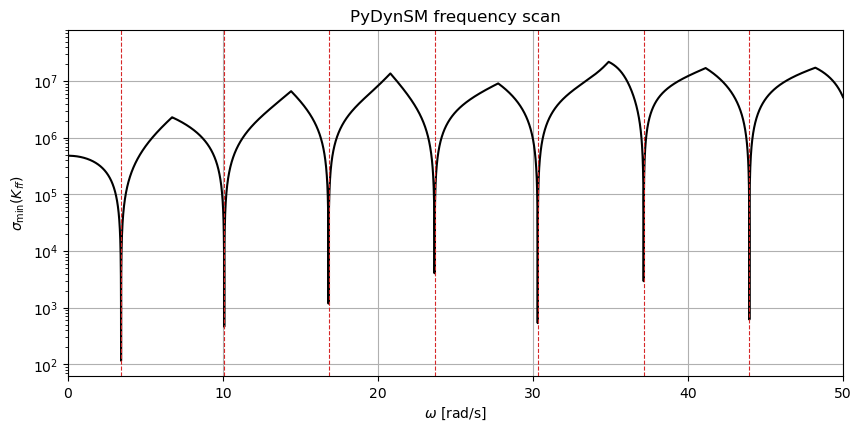

First 10 natural frequencies from the PyDynSM shear-beam model:
Mode  1: omega =   3.419640 rad/s,   f =   0.544253 Hz
Mode  2: omega =  10.076625 rad/s,   f =   1.603745 Hz
Mode  3: omega =  16.804546 rad/s,   f =   2.674527 Hz
Mode  4: omega =  23.645448 rad/s,   f =   3.763290 Hz
Mode  5: omega =  30.299538 rad/s,   f =   4.822321 Hz
Mode  6: omega =  37.135944 rad/s,   f =   5.910369 Hz
Mode  7: omega =  43.955431 rad/s,   f =   6.995724 Hz
Mode  8: omega =  50.652997 rad/s,   f =   8.061675 Hz
Mode  9: omega =  57.562316 rad/s,   f =   9.161327 Hz
Mode 10: omega =  64.319510 rad/s,   f =  10.236768 Hz

Reference frequencies from the earlier SymPy/script notebook [Hz]:
[ 0.544253,  1.603745,  2.674526,  3.76329 ,  4.822321,  5.910369,
  6.995724,  8.061674,  9.161327, 10.236768]
Maximum absolute difference [Hz]: 5.359335712995517e-07


In [6]:
soil, soil_nodes = build_soil_column()

omega_sample = 10.0
K_sample = constrained_matrix(soil, omega_sample)

print(f"Constrained PyDynSM matrix K_ff at omega = {omega_sample:.1f} rad/s:")
print(np.array2string(K_sample, precision=3, suppress_small=False))
print("\nMatrix size:", K_sample.shape)

omega_scan, sigma_scan, omega_n = find_natural_frequencies(
    soil,
    omega_min=0.1,
    omega_max=80.0,
    n_scan=20000,
    n_modes=10,
)
f_n = omega_n / (2.0 * np.pi)

plt.figure(figsize=(10, 4.5))
plt.semilogy(omega_scan, sigma_scan, color="black")
for omega in omega_n:
    plt.axvline(omega, color="tab:red", lw=0.8, ls="--")
plt.xlim(0.0, 50.0)
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$\sigma_{\min}(K_{ff})$")
plt.title("PyDynSM frequency scan")
plt.show()

print("First 10 natural frequencies from the PyDynSM shear-beam model:")
for i, (omega_i, f_i) in enumerate(zip(omega_n, f_n), start=1):
    print(f"Mode {i:2d}: omega = {omega_i:10.6f} rad/s,   f = {f_i:10.6f} Hz")

reference_digits = {"A": 6, "B": 6, "C": 1, "D": 1, "E": 2, "F": 5, "G": 7}
reference_f_hz = np.array(
    [
        0.5442529216690966,
        1.6037448632678133,
        2.674526416786751,
        3.7632900292680613,
        4.822321447146955,
        5.910368929110166,
        6.995724119939395,
        8.061674280460121,
        9.161326709183932,
        10.236767796332378,
    ]
)

if student_digits == reference_digits:
    print("\nReference frequencies from the earlier SymPy/script notebook [Hz]:")
    print(np.array2string(reference_f_hz, precision=6, separator=", "))
    print("Maximum absolute difference [Hz]:", np.max(np.abs(f_n - reference_f_hz)))


omega1 = 3.41963993 rad/s
First-mode nodal amplitudes [surface, interface 1, top layer 3, base]:
[1.         0.99588652 0.53100965 0.        ]


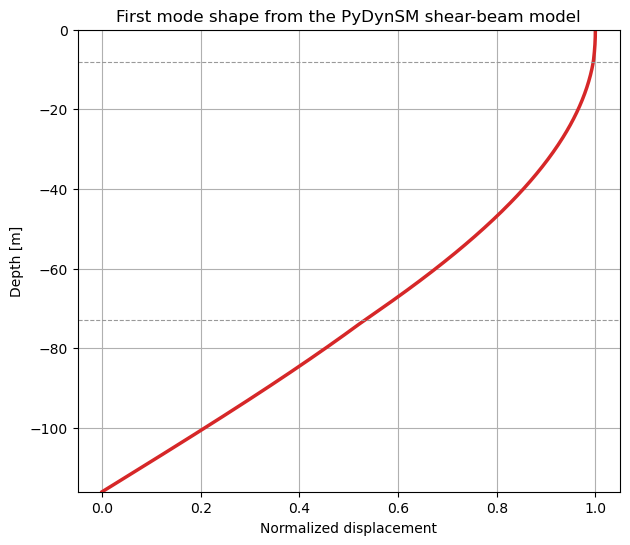

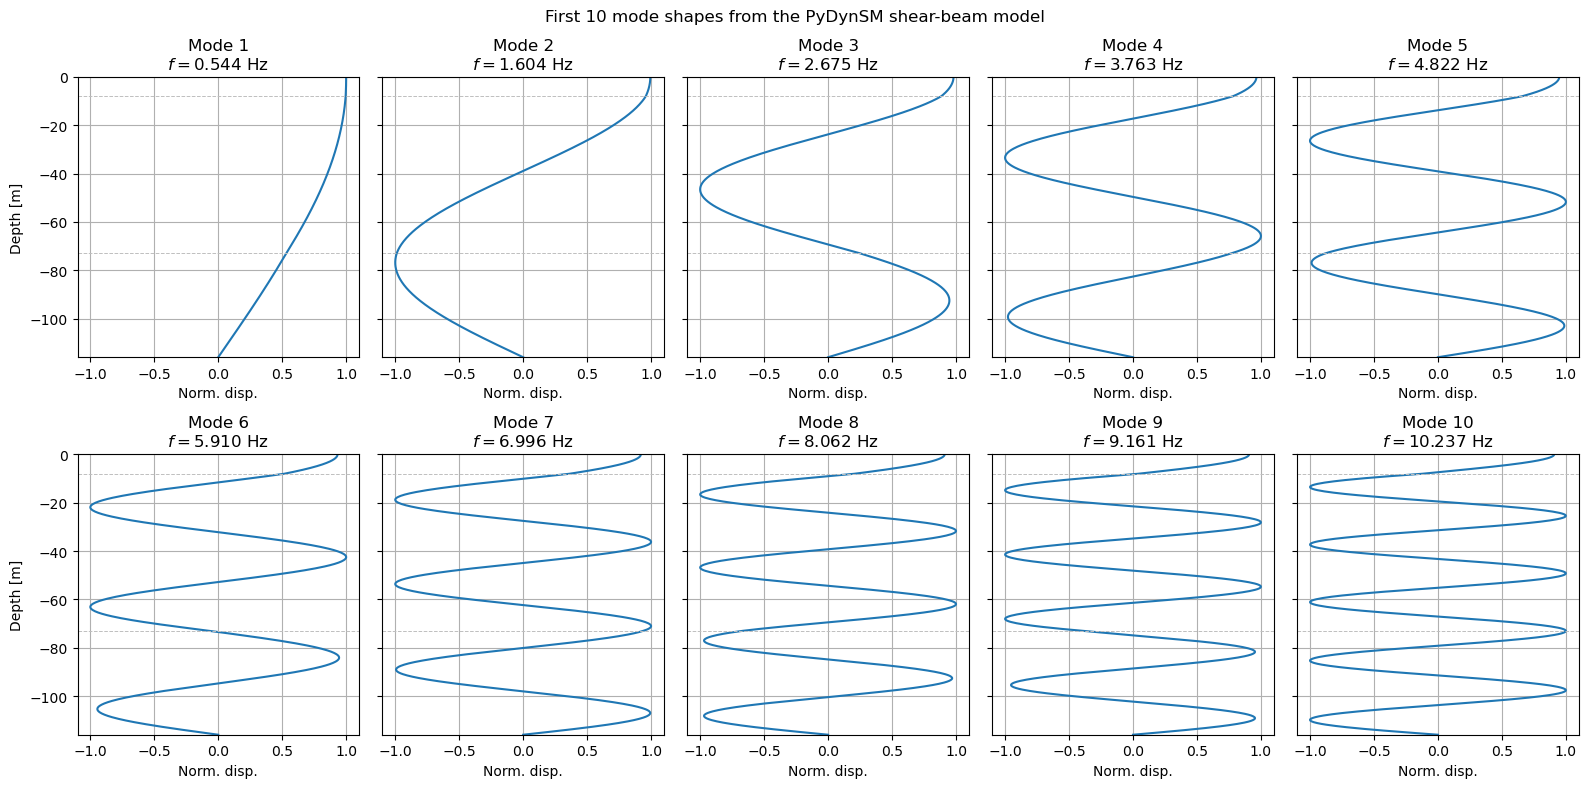

In [7]:
omega1 = omega_n[0]
depth_mode1, disp_mode1, u_mode1 = mode_profile(soil, omega1)

print(f"omega1 = {omega1:.8f} rad/s")
print("First-mode nodal amplitudes [surface, interface 1, top layer 3, base]:")
print(np.real_if_close(u_mode1 / np.max(np.abs(u_mode1[:-1]))))

plt.figure(figsize=(7, 6))
plt.plot(np.real(disp_mode1), depth_mode1, color="tab:red", lw=2.5)
for depth in depth_nodes[1:-1]:
    plt.axhline(depth, color="0.6", lw=0.8, ls="--")
plt.xlabel("Normalized displacement")
plt.ylabel("Depth [m]")
plt.title("First mode shape from the PyDynSM shear-beam model")
plt.ylim(depth_nodes[-1], depth_nodes[0])
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for i, (ax, omega_i) in enumerate(zip(axes, omega_n), start=1):
    depth_i, disp_i, _ = mode_profile(soil, omega_i)
    ax.plot(np.real(disp_i), depth_i, color="tab:blue")
    for depth in depth_nodes[1:-1]:
        ax.axhline(depth, color="0.75", lw=0.7, ls="--")
    ax.set_title(f"Mode {i}\n$f = {omega_i / (2*np.pi):.3f}$ Hz")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(depth_nodes[-1], depth_nodes[0])
    ax.set_xlabel("Norm. disp.")

axes[0].set_ylabel("Depth [m]")
axes[5].set_ylabel("Depth [m]")
fig.suptitle("First 10 mode shapes from the PyDynSM shear-beam model")
fig.tight_layout()
plt.show()


## Effect of Soil Damping on Natural Frequencies and Modes

If soil damping is included, the `PyDynSM` `Shear Beam` element uses a complex shear modulus of the form

$$
G_i^* = G_i (1 + 2 i \xi_i).
$$

The main consequences are the same as in the earlier notebook:

- the eigenvalues become complex
- the damped natural frequencies are usually slightly lower than the undamped ones
- free vibrations decay in time
- the mode shapes become complex-valued, so they carry both amplitude and phase variation with depth
- resonance peaks become lower and broader, and the phase changes become smooth instead of sharp jumps

To reproduce the same results as the undamped SymPy/Maple workflow, the present PyDynSM model is evaluated with `\xi_i = 0`.


## 3. Frequency Response Functions

For the forced-response problem, the same three-layer `PyDynSM` model is used. The only change is the base input.

If the bedrock acceleration is prescribed as

$$
a_g(t) = a_0 e^{i\omega t},
$$

then the corresponding harmonic displacement amplitude at the base is

$$
U_g = -\frac{a_0}{\omega^2}.
$$

The displacement FRF is

$$
H(z,\omega) = \frac{U(z)}{U_g},
$$

and because both numerator and denominator are multiplied by the same factor `-\omega^2`, the same complex ratio also gives the acceleration FRF:

$$
H(z,\omega) = \frac{a(z)}{a_0}.
$$


Check at omega = 10.0 rad/s:
Displacement ratio  U(surface)/U_g = (-28.777189848361285-0j)
Acceleration ratio a(surface)/a_0 = (-28.777189848361285+0j)
Difference = -0j


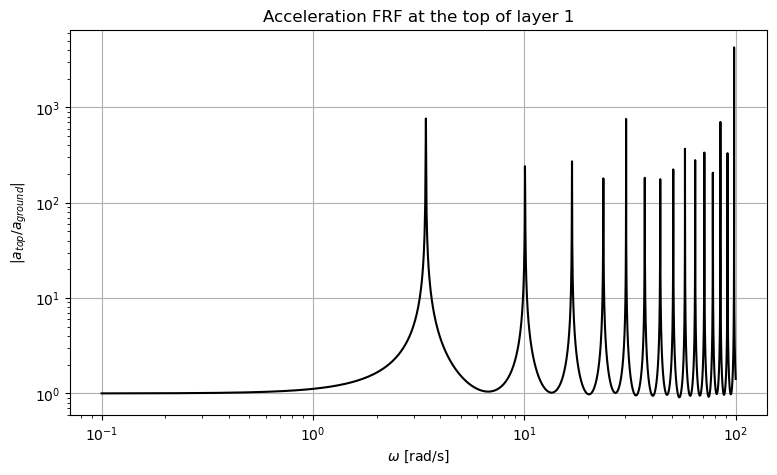

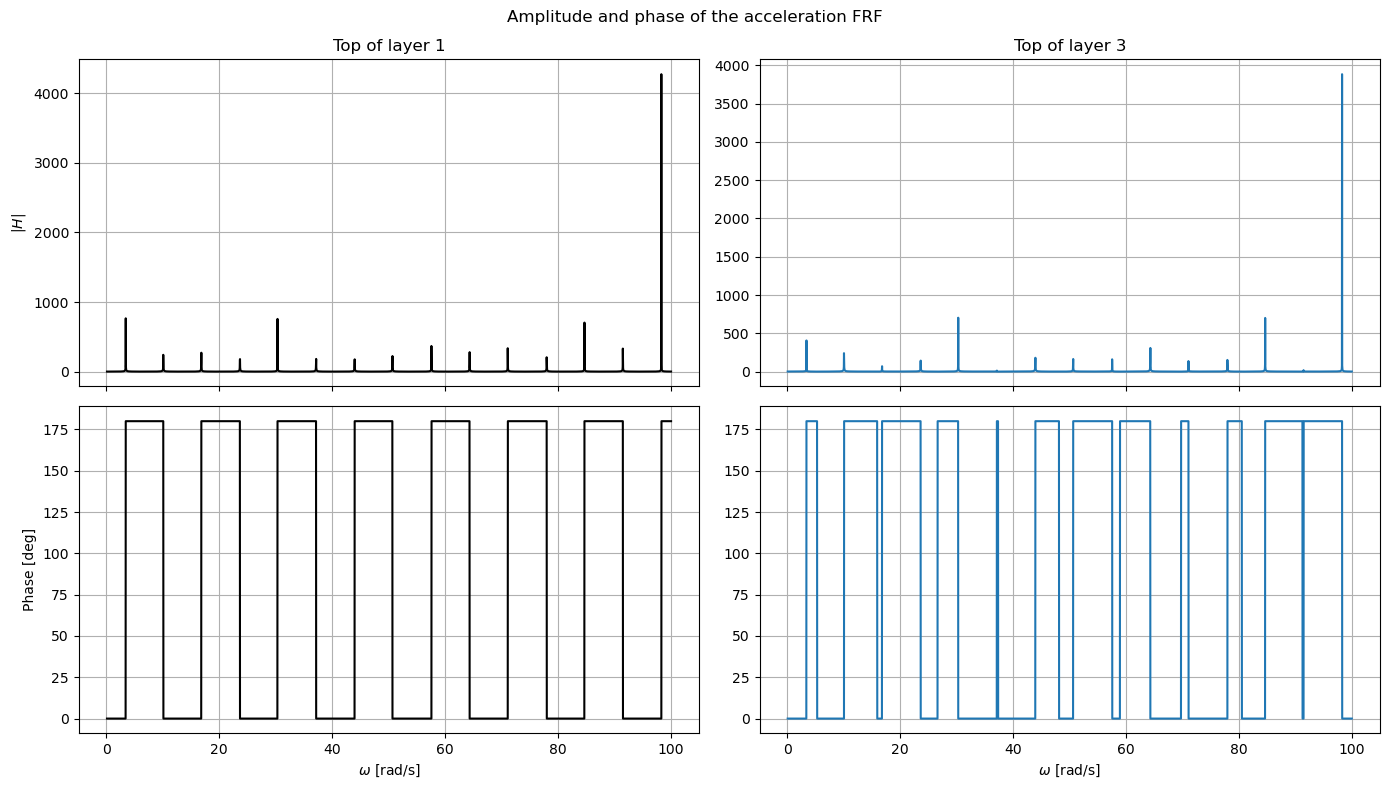

In [8]:
omega_frf = np.linspace(0.1, 100.0, 4000)
H_surface = np.array([acceleration_frf(soil, omega, location="surface") for omega in omega_frf])
H_top_layer3 = np.array([acceleration_frf(soil, omega, location="top_layer_3") for omega in omega_frf])

omega_check = 10.0
H_disp_check = displacement_ratio(soil, omega_check, location="surface")
H_acc_check = acceleration_frf(soil, omega_check, location="surface")

print(f"Check at omega = {omega_check:.1f} rad/s:")
print("Displacement ratio  U(surface)/U_g =", H_disp_check)
print("Acceleration ratio a(surface)/a_0 =", H_acc_check)
print("Difference =", H_disp_check - H_acc_check)

plt.figure(figsize=(9, 5))
plt.loglog(omega_frf, np.abs(H_surface), color="black")
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$|a_{top} / a_{ground}|$")
plt.title("Acceleration FRF at the top of layer 1")
plt.show()

phase_surface = np.angle(H_surface, deg=True)
phase_top_layer3 = np.angle(H_top_layer3, deg=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

axes[0, 0].plot(omega_frf, np.abs(H_surface), color="black")
axes[0, 0].set_ylabel(r"$|H|$")
axes[0, 0].set_title("Top of layer 1")

axes[0, 1].plot(omega_frf, np.abs(H_top_layer3), color="tab:blue")
axes[0, 1].set_title("Top of layer 3")

axes[1, 0].plot(omega_frf, phase_surface, color="black")
axes[1, 0].set_xlabel(r"$\omega$ [rad/s]")
axes[1, 0].set_ylabel("Phase [deg]")

axes[1, 1].plot(omega_frf, phase_top_layer3, color="tab:blue")
axes[1, 1].set_xlabel(r"$\omega$ [rad/s]")

fig.suptitle("Amplitude and phase of the acceleration FRF")
fig.tight_layout()
plt.show()


## Interpretation of Part 3

- The surface FRF is larger because the wave has travelled through all three layers and is additionally amplified by reflections at the free surface.
- The FRF at the top of layer 3 is closer to the imposed bedrock motion, so it shows less amplification than the surface.
- In the undamped model used here, the FRF is almost purely real, so the phase is mainly `0^\circ` or `180^\circ`.
- A phase of `0^\circ` means the response is in phase with the bedrock input, while `180^\circ` means the response has changed sign.
- If damping were included, the phase would vary smoothly through the resonant bands instead of jumping sharply.
